# Acoustic attenuation length in seawater
Auxiliary script to plot the absorption length of different absorption models used throughout the research, most of which have been covered by [Bevan et al.](https://www.sciencedirect.com/science/article/pii/S0168900209009401) 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
import report_plotstyle

# Constants

PI          = np.pi
conv_const  = 8.685889638   # converts dB/km to absorption length in km
eps         = 1e-20

In [3]:
def distilled(f_Hz, z_km=None):
    '''
    Real absorption of distilled water
    '''
    w0      = 1e12
    c       = 1500

    # attenuation coefficient (dB/km)
    alpha   = 1e4 / np.log(10) / w0 / c * (2 * PI * f_Hz)**2

    # absorption length (km)
    return np.where(alpha > eps, conv_const / alpha, np.inf)

def distilled_w0(f_Hz, z_km=None):
    '''
    Real absorption by viscous distilled water as a sea water approximation by Lehtinen
    '''
    w0      = 2.5e10
    c       = 1500

    # attenuation coefficient (dB/km)
    alpha   = 1e4 / np.log(10) / w0 / c * (2 * PI * f_Hz)**2

    # absorption length (km)
    return np.where(alpha > eps, conv_const / alpha, np.inf)

def ACoRNE(f_Hz, z_km=2, T_deg=15, S=37, pH=7.9):
    '''
    Complex absorption from the model proposed by Bevan et al.
    '''
    w = 2 * np.pi * f_Hz
    s = 1j * w

    w_B  = 2 * np.pi * 0.78e3 * np.sqrt(S / 35) * np.exp(T / 26)
    w_Mg = 2 * np.pi * 42e3 * np.exp(T_deg / 17)

    K_B  = 0.106e-3 * np.exp((pH - 8) / 0.56) / (2 * np.pi)
    K_Mg = 0.52e-3 * (1 + T_deg / 43) * (S / 35) * np.exp(-z_km / 6) / (2 * np.pi)
    K_W  = 0.00049e-6 * np.exp(-T_deg / 27 + z_km / 17) / (4 * np.pi**2)

    # attenuation (dB/km)
    alpha = (
        K_B  * w_B  * s / (s + w_B)
        + K_Mg * w_Mg * s / (s + w_Mg)
        + K_W  * w**2
    )

    alpha = np.real(alpha)   # imaginary should be zero except numerical noise

    # absorption length (km)
    return np.where(alpha > eps, conv_const / alpha, np.inf)

def AinslieMcColm(f_Hz, z_km=2, T_deg=15, S=37, pH=7.9):
    '''
    Complex absorption from the model proposed by Ainslie and McColm.
    '''
    f_kHz = f_Hz * 1e-3

    f1 = 0.78 * np.sqrt(S / 35) * np.exp(T_deg / 26)
    f2 = 42   * np.exp(T_deg / 17)

    # attenuation (dB/km)
    alpha = (
        0.106 * f1 * f_kHz**2 / (f_kHz**2 + f1**2) * np.exp((pH - 8)/0.56)
        + 0.52  * (1 + T_deg/43) * (S/35) * f2 * f_kHz**2 / (f_kHz**2 + f2**2) * np.exp(-z_km/6)
        + 0.00049 * f_kHz**2 * np.exp(-T_deg/27 + z_km/17)
    )

    # absorption length (km)
    return np.where(alpha > eps, conv_const / alpha, np.inf)


# Compute and plot

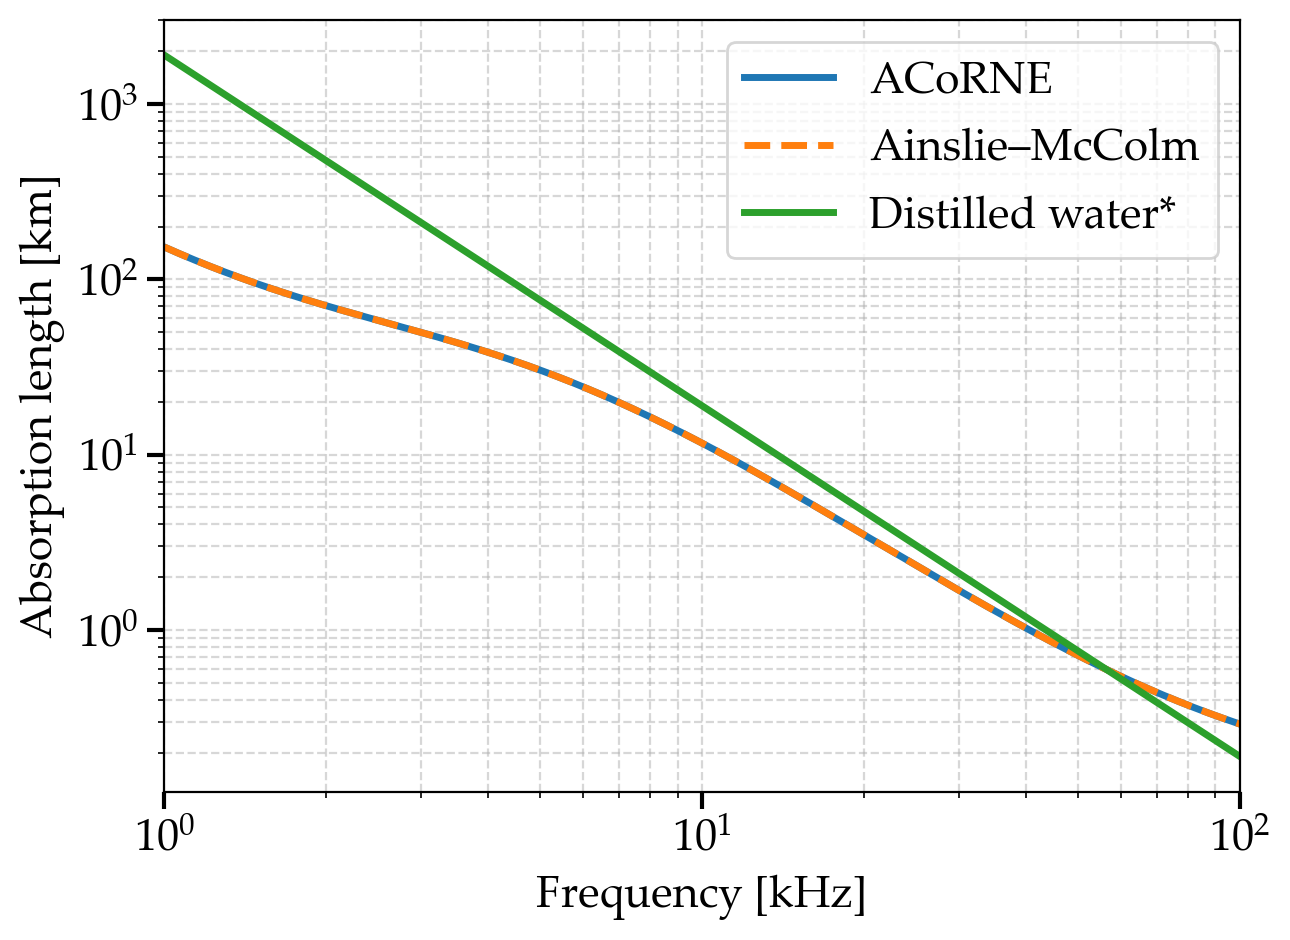

In [4]:
# frequency range
f = np.geomspace(1e3, 1e5, 1000)  # Hz
T = 13.2                          # deg 
S = 38                            # -
pH = 8                            # -

# absorption lengths (km)
L_acorne        = ACoRNE(f, 2, T, S, pH)
L_ainslie100    = AinslieMcColm(f, 0.1, T, S, pH)
L_ainslie2000   = AinslieMcColm(f, 2, T, S, pH)
L_distilled     = distilled(f)
L_distilled_w0  = distilled_w0(f)

# limit extreme values for plotting
max_L = 1e6
L_acorne        = np.minimum(L_acorne, max_L)
L_ainslie100    = np.minimum(L_ainslie100, max_L)
L_ainslie2000   = np.minimum(L_ainslie2000, max_L)
L_distilled     = np.minimum(L_distilled, max_L)
L_distilled_w0  = np.minimum(L_distilled_w0, max_L)

# corresponding attenuation α in dB/km
alpha_acorne        = conv_const / L_acorne
alpha_ainslie100    = conv_const / L_ainslie100
alpha_ainslie2000   = conv_const / L_ainslie2000
alpha_distilled     = conv_const / L_distilled
alpha_distilled_w0  = conv_const / L_distilled_w0

plt.figure()

# primary y-axis: absorption length (km)
plt.loglog(f / 1e3, L_acorne,       label="ACoRNE")
# ax1.loglog(f, L_ainslie100,   label="Ainslie–McColm, z= 100m")
plt.loglog(f / 1e3, L_ainslie2000, '--', label="Ainslie–McColm") # , z= 2000m
# ax1.loglog(f, L_distilled,    label="Distilled water")
plt.loglog(f / 1e3, L_distilled_w0, label=r"Distilled water*")

plt.xlabel("Frequency [kHz]")
plt.ylabel("Absorption length [km]")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.xlim(f[0] / 1e3, f[-1] / 1e3)
plt.show()